In [ ]:
import pandas as pd
import ast
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Definition der Stoppwortliste für den explorativen Ansatz (BGH)
# Entfernt werden nur strukturelle Begriffe, Rollen und Kalenderdaten
eugh_stop_explorativ = [
    # Institutionen & Instanzen
    'bundesgerichtshof', 'senat', 'vorinstanz', 'landgericht', 'oberlandesgericht', 
    'berufungsgericht', 'gerichtshof', 'kammer',
    
    # Prozessuale Rollen & Begriffe
    'kläger', 'klägerin', 'beklagte', 'beklagter', 'revisionskläger', 'revisionsbeklagte',
    'revision', 'berufung', 'aktenzeichen', 'urteil', 'beschluss', 'entscheidung',
    
    # Zitierweise & Struktur
    'artikel', 'absatz', 'buchstabe', 'ziffer', 'paragraf', 'randnummer', 'seite', 'abs',
    
    # Kalenderdaten & Zeitbegriffe (da sie keine Sachthemen sind)
    'januar', 'februar', 'märz', 'april', 'mai', 'juni', 'juli', 'august', 
    'september', 'oktober', 'november', 'dezember', 'jahr', 'monat', 'datum', 'zeitpunkt',
    
    # Technische Kürzel & Füllwörter
    'sowie', 'beziehungsweise', 'gmbh', 'bghz', 'njw', 'beckrs', 'nr', 'anhängig'
]

print("✅ Setup abgeschlossen und Stoppwörter für die BGH-Analyse definiert.")

✅ Setup abgeschlossen und Stoppwörter für die BGH-Analyse definiert.


In [ ]:
# 1. Daten laden
df = pd.read_csv('Urteile_Bereinigt.csv')

# 2. Filter auf BGH
df_bgh = df[df['Gericht'] == 'BGH'].copy()

# 3. Jährliche Bündelung der Texte
# Ich gruppiere nach Jahr und füge die Nomen zu einem langen Text pro Jahr zusammen
df_yearly_bgh = df_bgh.groupby('Jahr')['Text_Nomen'].apply(lambda x: ' '.join(map(str, x))).reset_index()

print(f"✅ Daten geladen: {len(df_bgh)} BGH-Urteile gefunden.")
print(f"✅ Analysezeitraum: {df_yearly_bgh['Jahr'].min()} bis {df_yearly_bgh['Jahr'].max()}.")

✅ Daten geladen: 135 BGH-Urteile gefunden.
✅ Analysezeitraum: 2020 bis 2025.


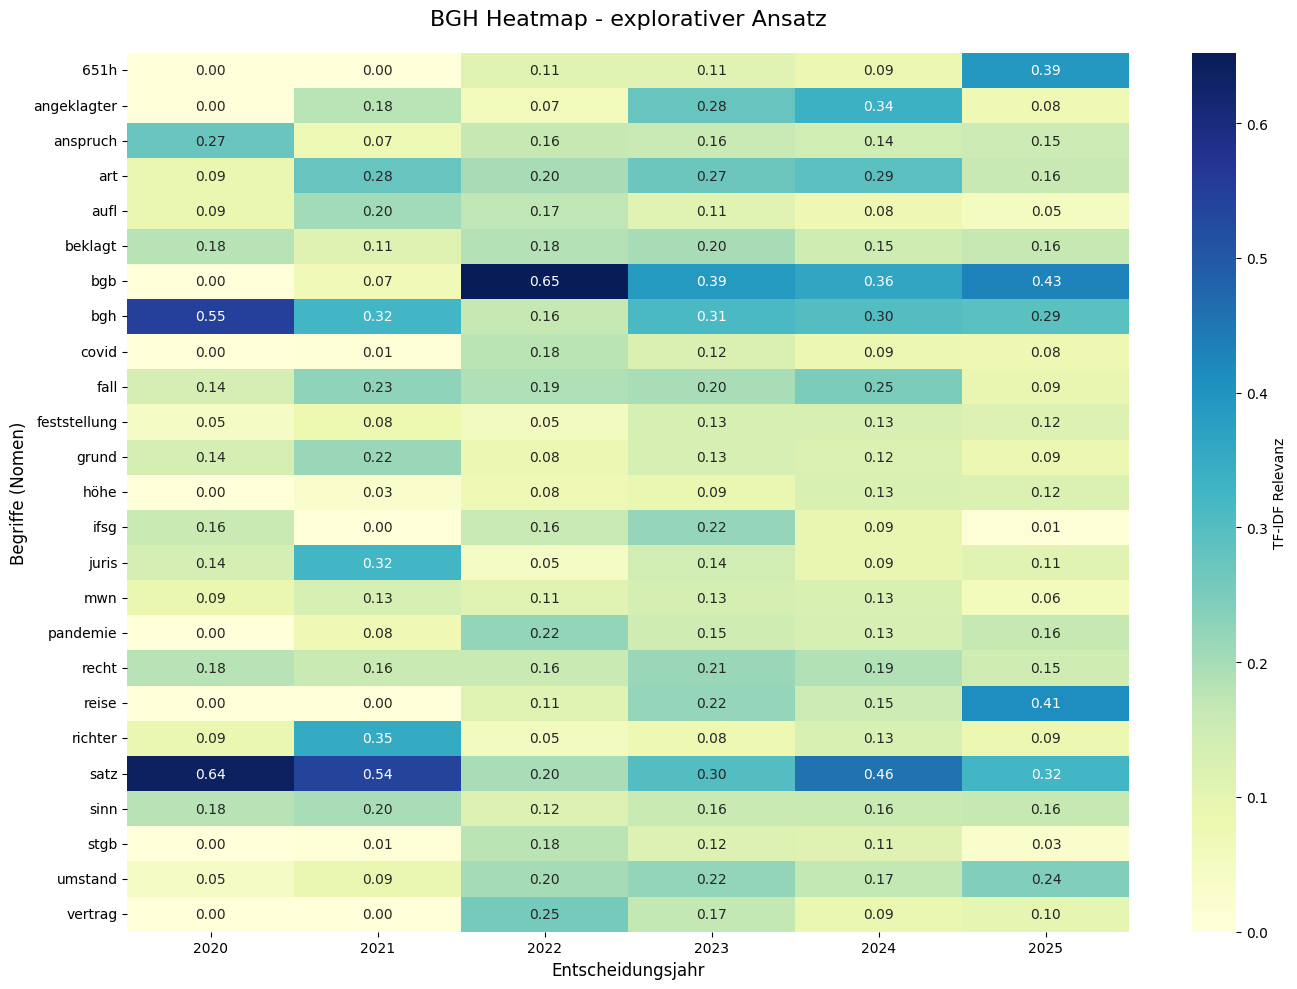

In [ ]:
# 1. TF-IDF Konfiguration (Explorativer Ansatz)
# Ich nutze max_df=1.0, um alle Begriffe im Kontext zu sehen
tfidf_vectorizer = TfidfVectorizer(
    stop_words=eugh_stop_explorativ, 
    max_df=1.0, 
    min_df=1,
    max_features=25,             # Beschränkung auf die Top 25 Merkmale
    token_pattern=r"(?u)\b\w\w\w+\b" # Nur Wörter mit mind. 3 Zeichen
)

# 2. Berechnung der Matrix
tfidf_matrix = tfidf_vectorizer.fit_transform(df_yearly_bgh['Text_Nomen'])

# 3. Erstellung des DataFrames für die Visualisierung
heatmap_data = pd.DataFrame(
    tfidf_matrix.toarray(), 
    index=df_yearly_bgh['Jahr'], 
    columns=tfidf_vectorizer.get_feature_names_out()
)

# 4. Plotten der Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_data.T, 
    annot=True, 
    fmt=".2f", 
    cmap='YlGnBu', 
    cbar_kws={'label': 'TF-IDF Relevanz'}
)

plt.title('BGH Heatmap - explorativer Ansatz', fontsize=16, pad=20)
plt.xlabel('Entscheidungsjahr', fontsize=12)
plt.ylabel('Begriffe (Nomen)', fontsize=12)
plt.tight_layout()

# Grafik für die Hausarbeit speichern
plt.savefig('BGH_Heatmap_Explorativ.png', dpi=300)
plt.show()

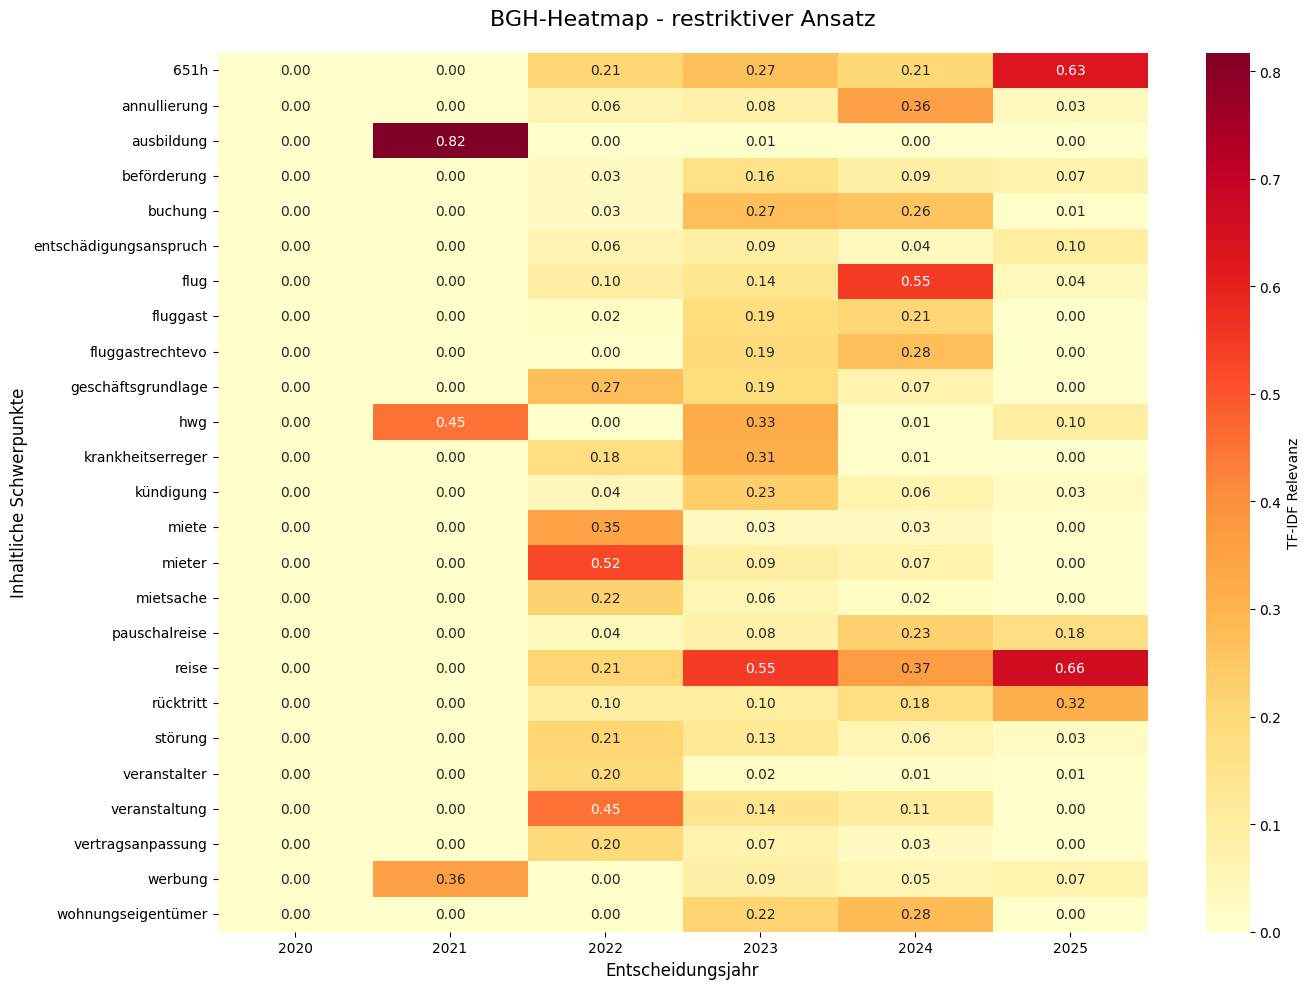

In [ ]:
# --- ZELLE 4: Restriktiver Ansatz (Finaler inhaltlicher Fokus) ---

# Erweiterung der die Liste um die identifizierten Störfaktoren und Hinzufügen weiterer inhaltshohler Nomen
eugh_stop_restriktiv = eugh_stop_explorativ + [
    'art', 'aufl', 'beklagt', 'bgh', 'fall', 'grund', 'höhe', 'juris', 
    'richter', 'satz', 'sinn', 'stgb', 'bgb', 'umstand', 'feststellung',
    'anspruch', 'recht', 'kosten', 'streitwert', 'entscheidung', 'vorbringen',
    'erfolg', 'land', 'strafkammer', 'angeklagter', 'mwn', 'revision', 'verurteilung', 'euro', 'vertrag', 'frankfurt', 'main', 'rra', 'xii', 'vi', 'beck', 'reisepreis', 'reiseveranstalter', 'reiseleistung', 'mail', 'anzahlung', 'bestimmungsort', 'eröffnung', 'rückzahlung', 'reisend', 'schaden', 'nzm', 'bacher', 'sars', 'cov', 'zins', 'versicherungsnehmer', 'geschädigt', 'aussage', 'entschädigung', 'uwg', 'reisezeitraum', 'vereinbarung', 'hoffmann', 'sachverständige', 'betrieb', 'vertragsschluss'
]

# 1. TF-IDF Konfiguration
# Ich setze max_df=0.8, um Dauerbrenner automatisch zu eliminieren
tfidf_bgh_res = TfidfVectorizer(
    stop_words=eugh_stop_restriktiv, 
    max_df=0.8,                  
    min_df=1, 
    max_features=25,             
    token_pattern=r"(?u)\b\w\w\w+\b"
)

# 2. Matrix berechnen
matrix_bgh_res = tfidf_bgh_res.fit_transform(df_yearly_bgh['Text_Nomen'])
heatmap_bgh_res = pd.DataFrame(
    matrix_bgh_res.toarray(), 
    index=df_yearly_bgh['Jahr'], 
    columns=tfidf_bgh_res.get_feature_names_out()
)

# 3. Visualisierung (Orange-Rot wie beim EuGH für den Fokus)
plt.figure(figsize=(14, 10))
sns.heatmap(
    heatmap_bgh_res.T, 
    annot=True, 
    fmt=".2f", 
    cmap='YlOrRd', 
    cbar_kws={'label': 'TF-IDF Relevanz'}
)

plt.title('BGH-Heatmap - restriktiver Ansatz', fontsize=16, pad=20)
plt.xlabel('Entscheidungsjahr', fontsize=12)
plt.ylabel('Inhaltliche Schwerpunkte', fontsize=12)
plt.tight_layout()

# Speichern für die Hausarbeit
plt.savefig('BGH_Heatmap_Restriktiv.png', dpi=300)
plt.show()